## This should be more or less the same Q-Q-plot result as in dataprep!

In [1]:
import statsmodels.api as sm
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../lifestyle_sustainability_data_processed.csv")
df.head(5)

,Age,LocalFoodFrequency,HomeSize,ClothingFrequency,SustainableBrands,EnvironmentalAwareness,CommunityInvolvement,MonthlyElectricityConsumption,MonthlyWaterConsumption,UsingPlasticProducts,...,EnergySource_Mixed,EnergySource_Non-Renewable,HomeType_Apartment,HomeType_House,Gender_Female,Gender_Male,Gender_Non-Binary,DisposalMethods_Combination,DisposalMethods_Composting,DisposalMethods_Landfill
0,35,2,800,0,1,5,2.0,100,1500,1,...,0,0,1,0,1,0,0,0,1,0
1,28,1,1500,1,1,4,1.0,250,3000,2,...,1,0,0,1,0,1,0,0,0,0
2,65,0,2500,2,0,2,0.0,400,4500,3,...,0,1,0,1,0,1,0,0,0,1
3,42,2,950,1,1,4,1.0,150,2000,1,...,0,0,1,0,1,0,0,0,0,0
4,31,1,1800,2,1,3,0.0,300,3500,2,...,1,0,0,1,0,0,1,1,0,0


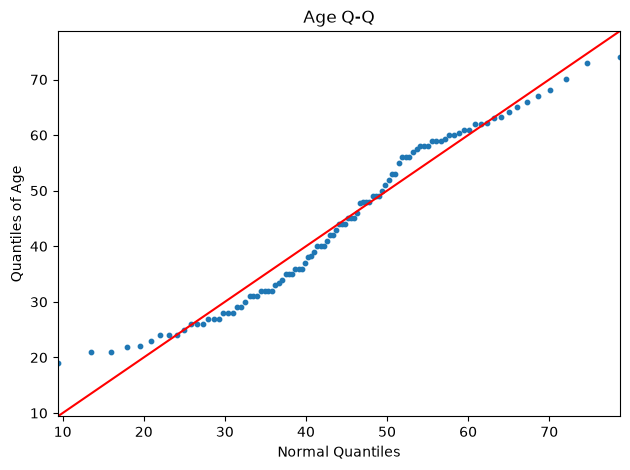

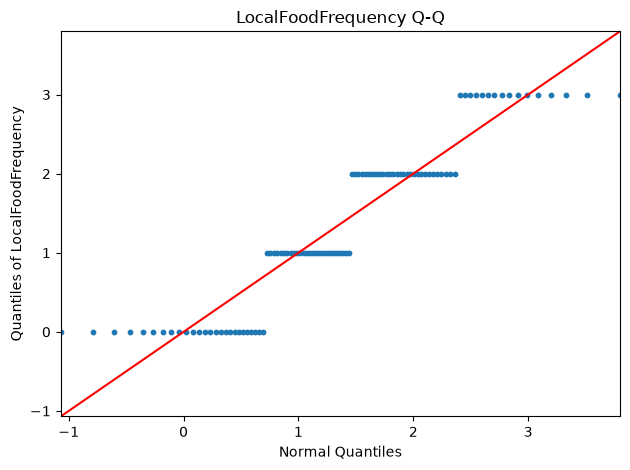

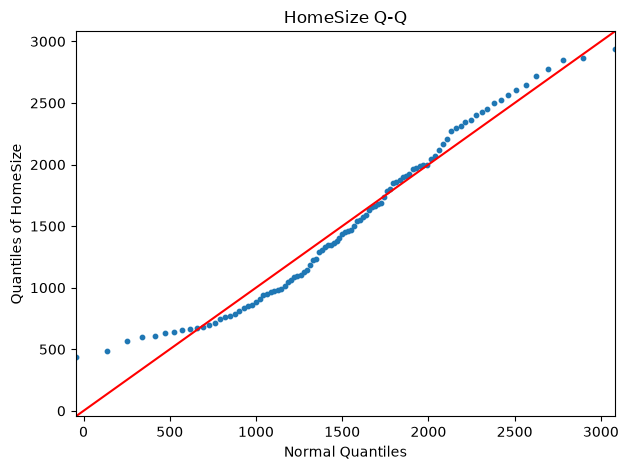

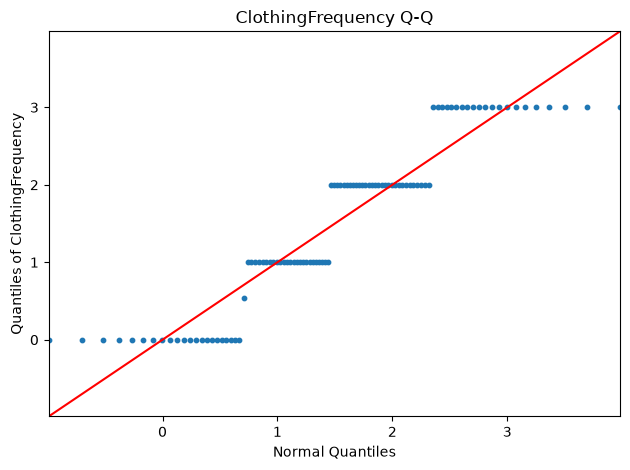

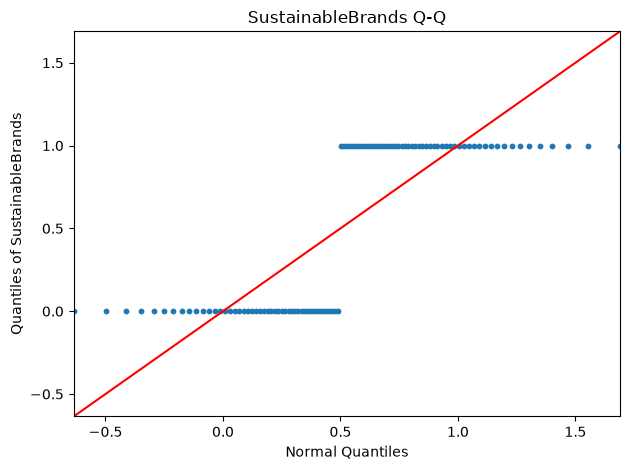

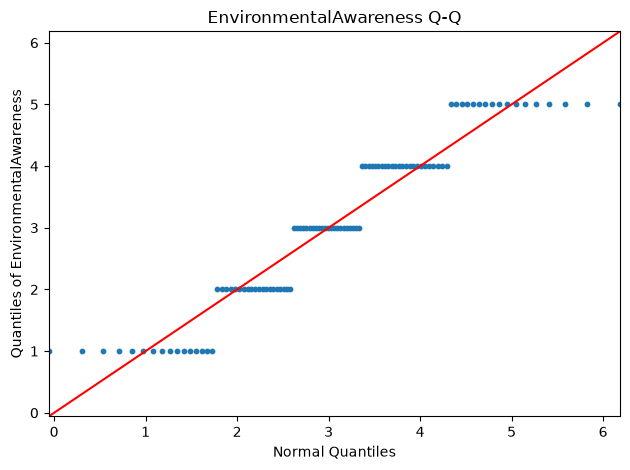

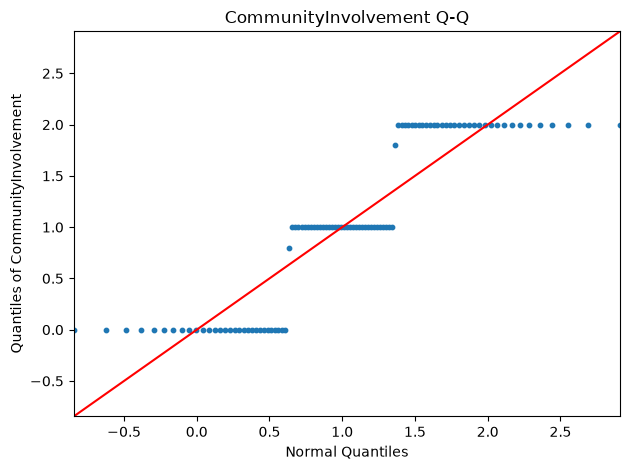

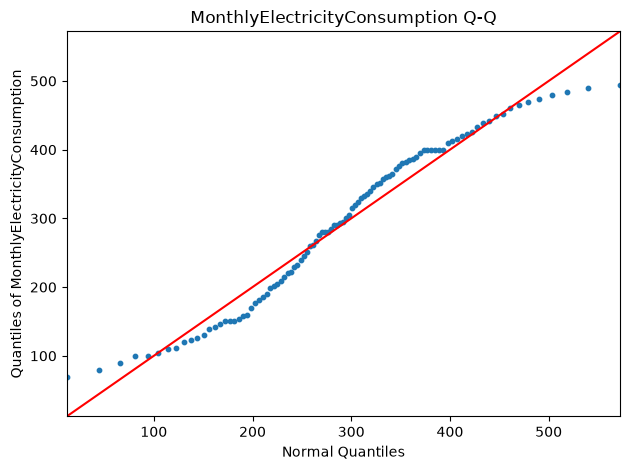

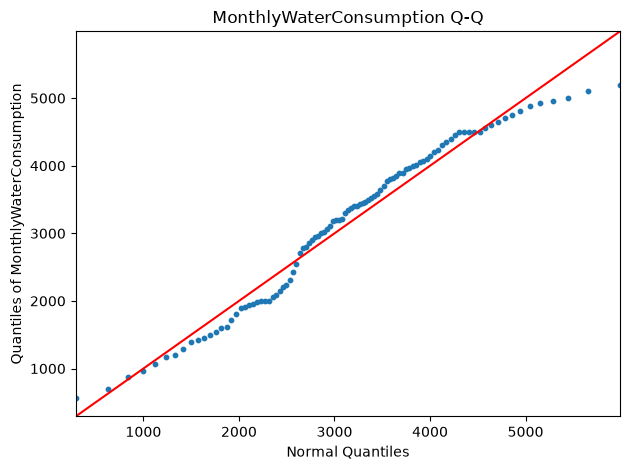

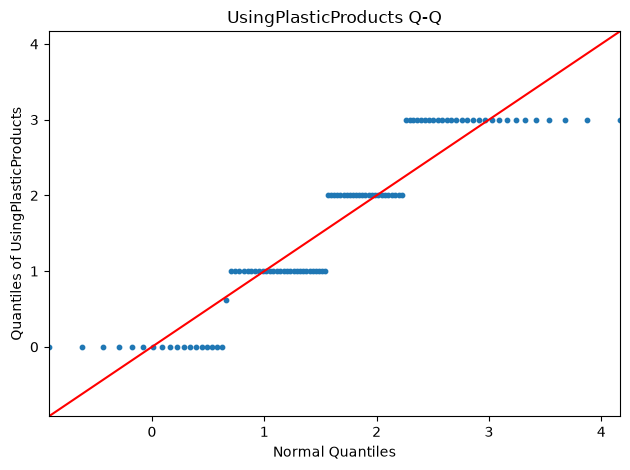

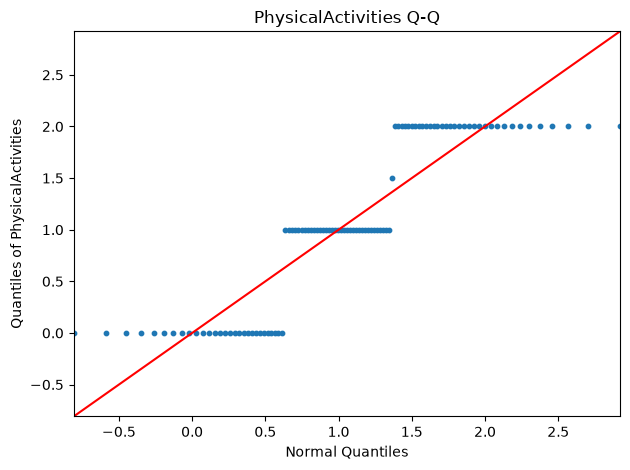

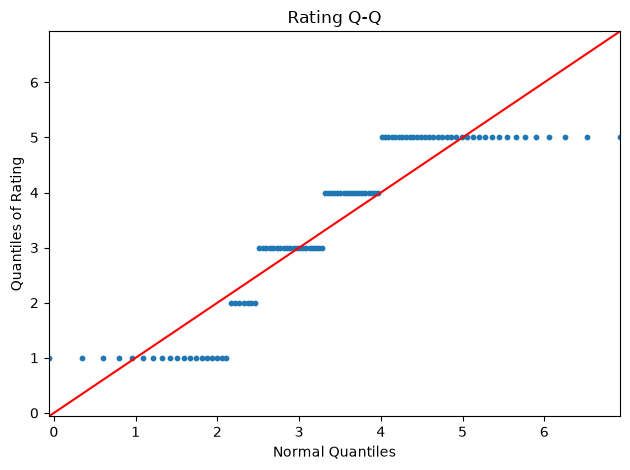

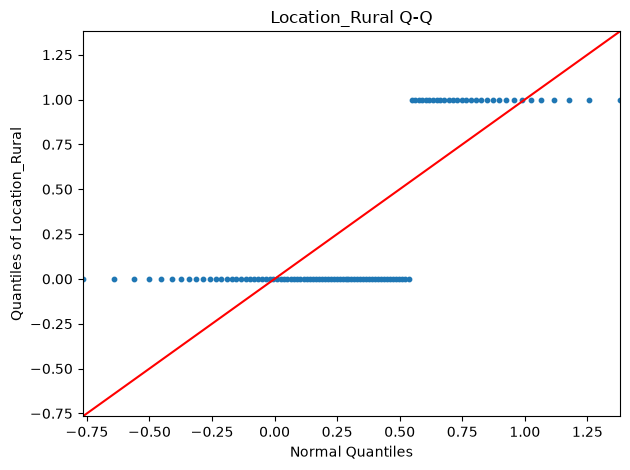

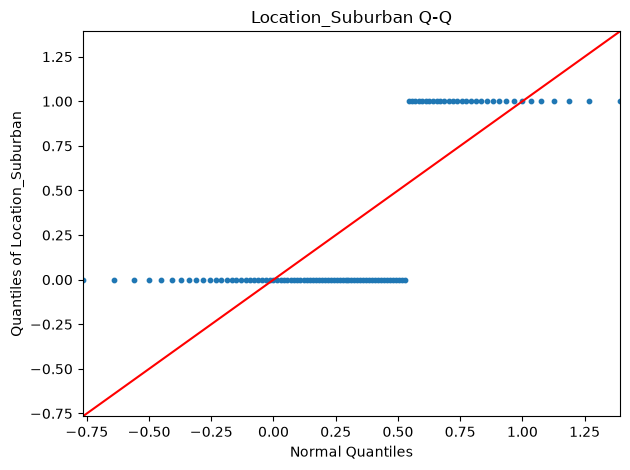

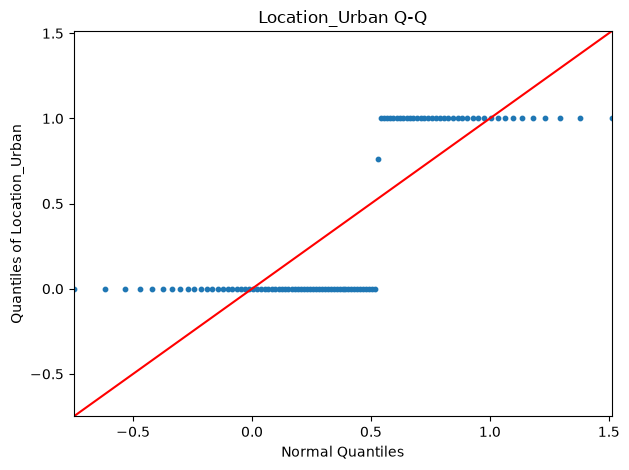

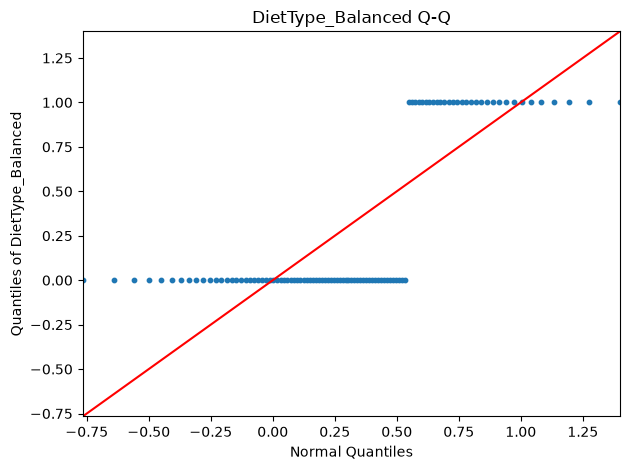

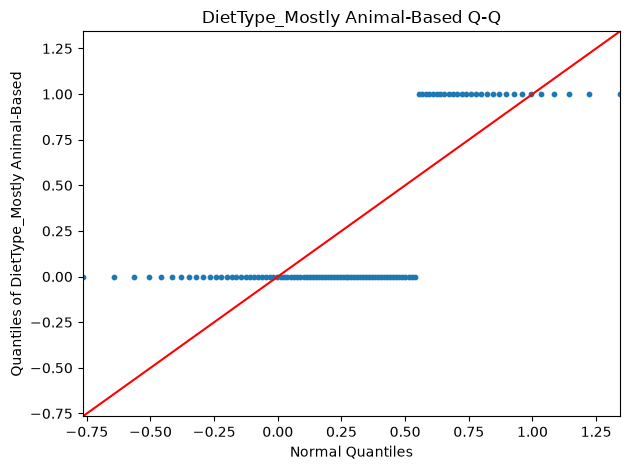

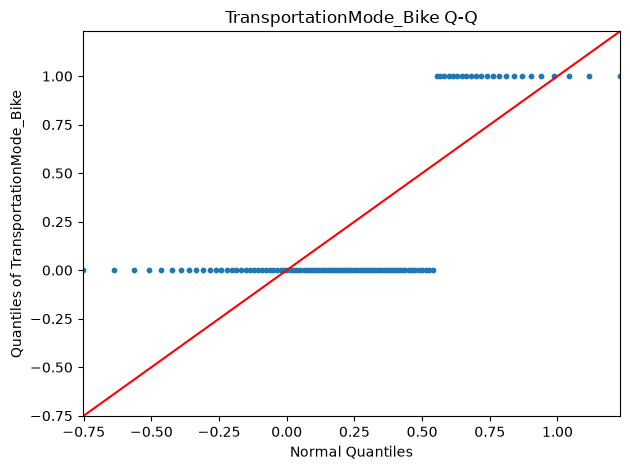

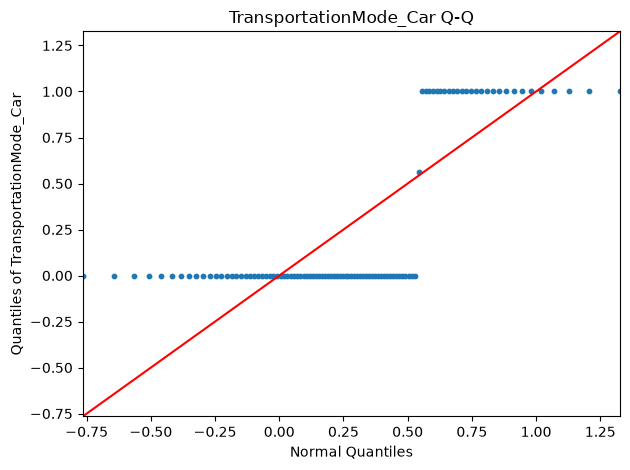

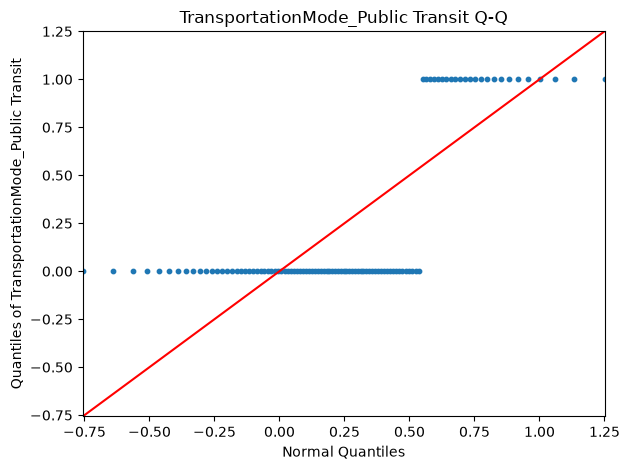

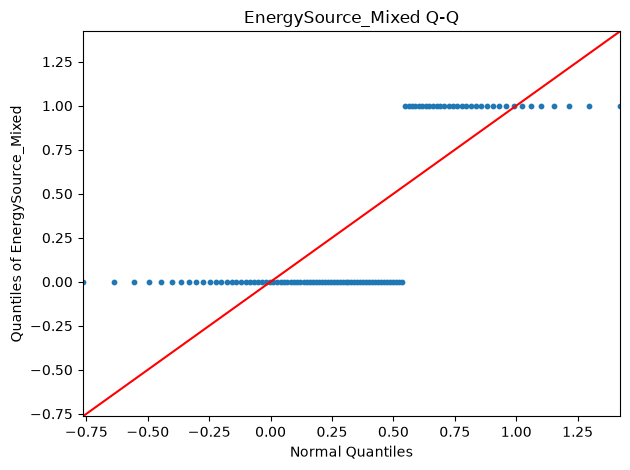

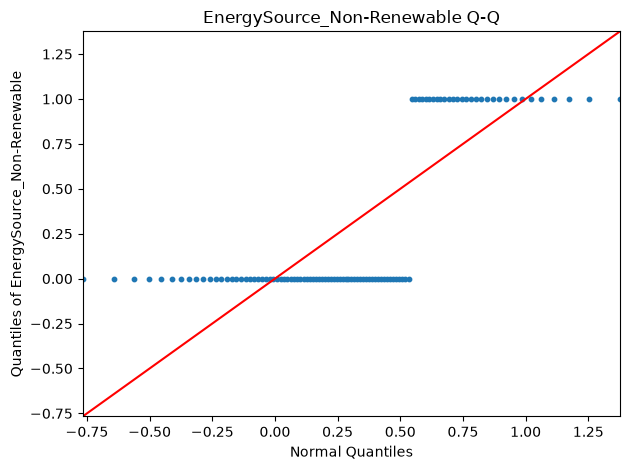

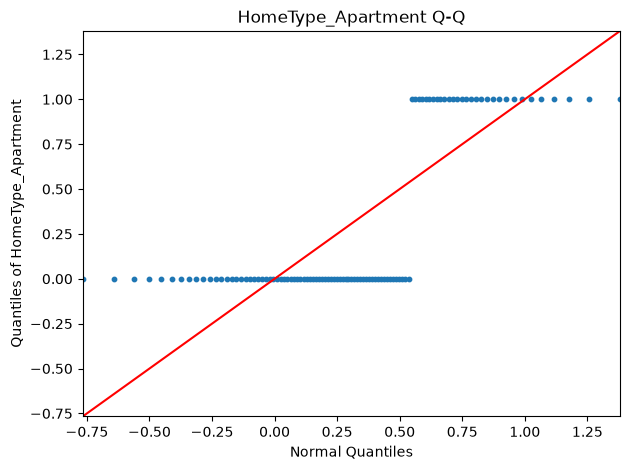

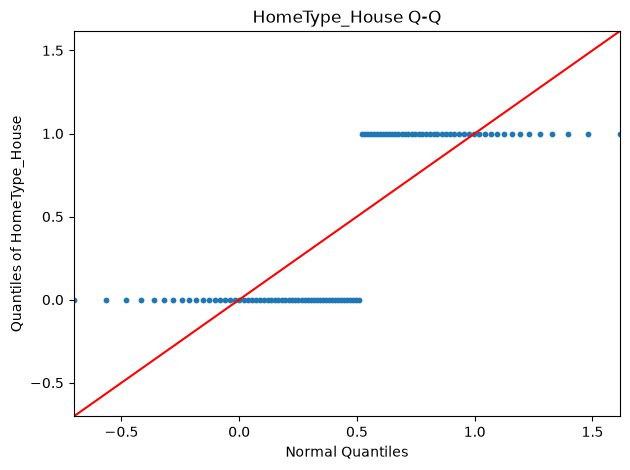

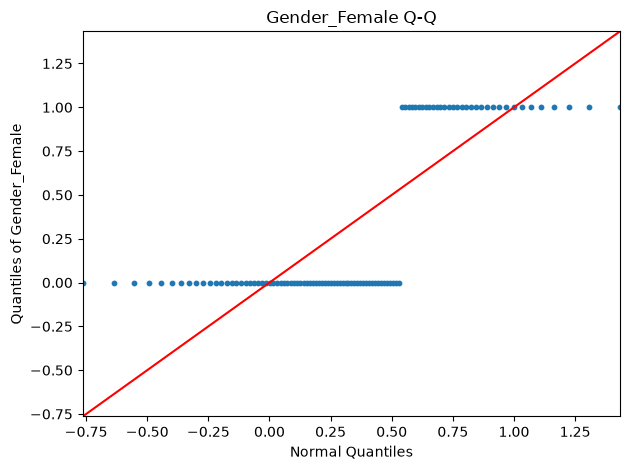

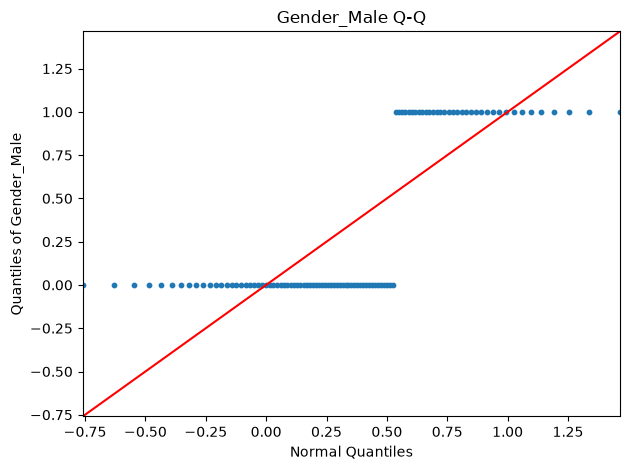

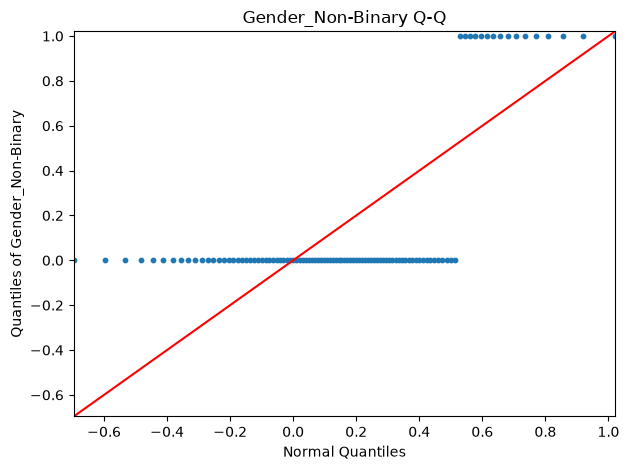

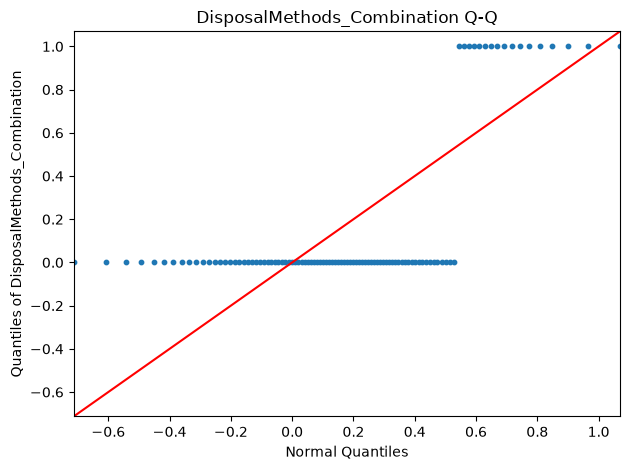

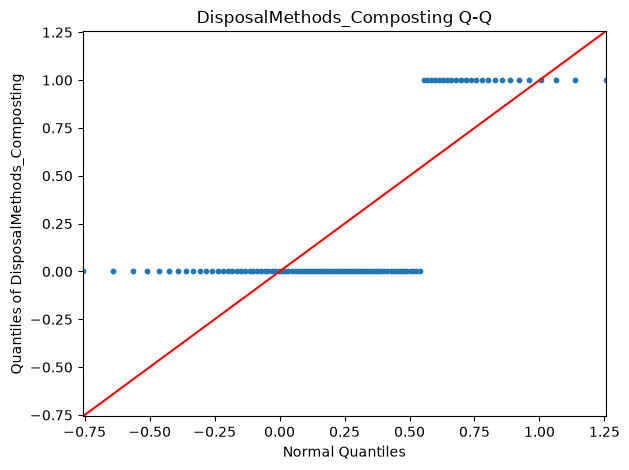

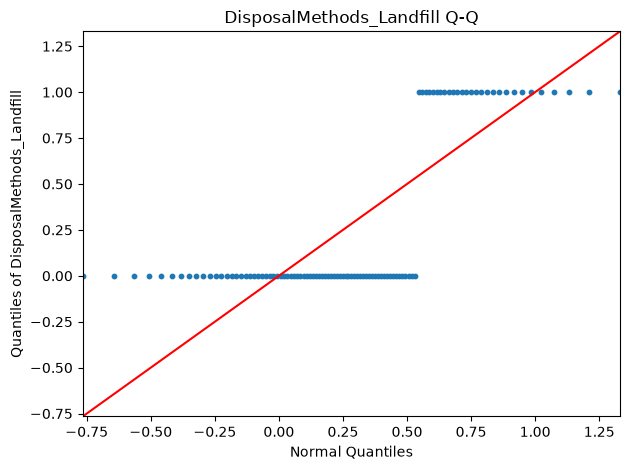

In [2]:
# This snippet displays the Q-Q plots for each numeric column!

import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

for column in df.columns:

    # Get rid of any non-numerical columns.
    if pd.api.types.is_numeric_dtype(df[column]):

        # Drop missing values in case it causes problems
        values = df[column].dropna()

        # Fit a normal distribution to THIS column's own scale.
        mean, std = values.mean(), values.std()

        # Make 99 percentiles, evenly spaced.
        probs = np.linspace(0.01, 0.99, 99)

        # Copies dataprep's method. take the sample of the quantiles.
        sample_qntls = values.quantile(probs)

        # Theoretical quantiles: what a perfectly normal distribution with
        # the datas mean and std would look like at each %
        theory_qntls = norm.ppf(probs, mean, std)

        # Combine both sets to find a shared min/max.
        vals = np.concatenate([sample_qntls, theory_qntls])
        lo, hi = vals.min(), vals.max()
        fig, ax = plt.subplots()

        # Plot sample quantiles with theoretical quantiles.
        ax.scatter(theory_qntls, sample_qntls, s=10)

        # Draw a diagonal line.
        ax.plot([lo, hi], [lo, hi], color="r")

        # Force both axes to the same range. Makes the 45 degrees fixed.
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)

        ax.set_title(f"{column} Q-Q")
        ax.set_xlabel("Normal Quantiles")
        ax.set_ylabel(f"Quantiles of {column}")

        plt.tight_layout()
        plt.show()